# Notebook 05 (rank-64) - MVP 1 Text-Only Run D at LoRA rank 64

Single-variable rank-capacity ablation of the locked MVP 1 baseline (NB 05d, Run D, rank 32, lr 3e-4).

**Changes vs Run D:**
- `lora_rank`: 32 -> **64**
- `lora_alpha`: 64 -> **128** (keeps 2x ratio)
- `epochs`: 5 -> **10**

All other settings (lora_lr=3e-4, head_lr=1e-3, focal BCE gamma=2, pos_weight=3.5739, seed=42, data, splits, scheduler, mixed precision, grad accum) identical to Run D. Output paths point to `models/rank64/roberta_run_d_r64[_best]/` and `outputs/nb05_r64_*.png` so no existing NB 05d artefact is touched.


In [1]:
import os, sys, json, random, gc, time, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    print(f'gpu mem: {torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB')

HPARAMS = dict(
    max_len=128,
    batch_size=16,
    epochs=10,
    lora_rank=64,
    lora_alpha=128,
    lora_lr=3e-4,
    head_lr=1e-3,
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    weight_decay=0.01,
    base_model='cardiffnlp/twitter-roberta-base-2022-154m',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    run_label='rank64_pipeline_mvp1_r64',
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
OUT_DIR = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'rank64' / 'roberta_run_d_r64'
BEST_DIR = ROOT / 'models' / 'rank64' / 'roberta_run_d_r64_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PROTECTED = [ROOT / 'models' / 'roberta_pretrain',
             ROOT / 'models' / 'roberta_mvp1',
             ROOT / 'models' / 'roberta_mvp1_best',
             ROOT / 'models' / 'roberta_mvp1_iter1',
             ROOT / 'models' / 'roberta_mvp1_fresh',
             ROOT / 'models' / 'roberta_mvp1_fresh_best']
for p in PROTECTED:
    print(f'  protected (will NOT touch): {p}  exists={p.exists()}')

print('ROOT:', ROOT)
print('LABELS_CSV exists:', LABELS_CSV.exists())
print('SPLITS_DIR exists:', SPLITS_DIR.exists())

device: cuda | NVIDIA L4
gpu mem: 22.03 GB
  max_len: 128
  batch_size: 16
  epochs: 10
  lora_rank: 64
  lora_alpha: 128
  lora_lr: 0.0003
  head_lr: 0.001
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  weight_decay: 0.01
  base_model: cardiffnlp/twitter-roberta-base-2022-154m
  prior_hate: 0.2468
  prior_nothate: 0.7532
  run_label: rank64_pipeline_mvp1_r64
  seed: 42
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_pretrain  exists=True
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1  exists=False
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_best  exists=True
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_iter1  exists=True
  protected (will NOT touch): /teamspace/studios/this_studio/HateFusion/models/roberta_mvp1_fresh  exists=True
  protected (will NOT touch): /teamspace/studios/this

In [2]:
df = pd.read_csv(LABELS_CSV)
print('raw shape:', df.shape, '| nulls:', df.isna().sum().to_dict())

def read_ids(p):
    return set(int(line.strip()) for line in open(p) if line.strip())

splits = {
    'train': read_ids(SPLITS_DIR / 'train_ids.txt'),
    'val':   read_ids(SPLITS_DIR / 'val_ids.txt'),
    'test':  read_ids(SPLITS_DIR / 'test_ids.txt'),
}
print(f'official split sizes (from txt files): '
      f'train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')

def assign_split(tid):
    for name, s in splits.items():
        if tid in s:
            return name
    return 'unassigned'

df['split'] = df['tweet_id'].map(assign_split)
df = df[df['split'].isin(['train', 'val', 'test'])].reset_index(drop=True)

print('\npost-join shape:', df.shape, '| nulls:', df.isna().sum().to_dict())
print('\nper-split T1 distribution:')
print(f'  {"split":<6} {"n":>7} {"%hate":>7} {"hate":>7} {"nothate":>8}')
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    pct = sub['T1'].mean() * 100
    print(f'  {s:<6} {len(sub):>7} {pct:>6.2f}% {int(sub["T1"].sum()):>7} {(sub["T1"] == 0).sum():>8}')
print('\nExpected per Gomez 2019 design: train ~22% hate, val/test 50% balanced. Confirmed.')

raw shape: (149819, 10) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0}
official split sizes (from txt files): train=134823 val=5000 test=10000



post-join shape: (149819, 11) | nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 11710, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'split': 0}

per-split T1 distribution:
  split        n   %hate    hate  nothate
  train   134820  21.86%   29476   105344
  val       4999  50.01%    2500     2499
  test     10000  50.01%    5001     4999

Expected per Gomez 2019 design: train ~22% hate, val/test 50% balanced. Confirmed.


In [3]:
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['base_model'])
print(f'tokenizer: {tokenizer.__class__.__name__} | vocab: {tokenizer.vocab_size} | loaded from: {HPARAMS["base_model"]} (HF Hub)')

class MMHS150KTextDataset(Dataset):
    """Pre-tokenized text-only dataset for MMHS150K T1.
    Hashtags, mentions, URLs preserved verbatim per CLAUDE.md §3."""

    def __init__(self, sub_df, tok, max_len):
        texts = sub_df['tweet_text'].astype(str).tolist()
        enc = tok(texts, truncation=True, padding='max_length',
                  max_length=max_len, return_tensors='pt')
        self.input_ids = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        self.labels = torch.tensor(sub_df['T1'].to_numpy(dtype=np.float32))
        self.tweet_ids = torch.tensor(sub_df['tweet_id'].to_numpy(dtype=np.int64))

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'label': self.labels[idx],
            'tweet_id': self.tweet_ids[idx],
        }

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'val'].reset_index(drop=True)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f'split frames: train {train_df.shape} | val {val_df.shape} | test {test_df.shape}')
print(f'train_df nulls: {train_df.isna().sum().to_dict()}')

print('tokenising (one pass per split)...')
_t = time.time()
train_ds = MMHS150KTextDataset(train_df, tokenizer, HPARAMS['max_len'])
val_ds   = MMHS150KTextDataset(val_df,   tokenizer, HPARAMS['max_len'])
test_ds  = MMHS150KTextDataset(test_df,  tokenizer, HPARAMS['max_len'])
print(f'  done in {time.time()-_t:.1f}s. datasets: train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False,
                          num_workers=2, pin_memory=True)
print('sample (first 30 toks):', tokenizer.decode(train_ds[0]['input_ids'][:30]))

tokenizer: RobertaTokenizer | vocab: 50265 | loaded from: cardiffnlp/twitter-roberta-base-2022-154m (HF Hub)
split frames: train (134820, 11) | val (4999, 11) | test (10000, 11)
train_df nulls: {'tweet_id': 0, 'tweet_text': 0, 'img_filename': 0, 'labels': 0, 'labels_str': 0, 'T1': 0, 'T2': 9319, 'T3': 0, 'n_annotators': 0, 't2_valid': 0, 'split': 0}
tokenising (one pass per split)...


  done in 22.7s. datasets: train 134820 | val 4999 | test 10000
sample (first 30 toks): <s>@FriskDontMiss Nigga https://t.co/cAsaLWEpue</s><pad><pad><pad><pad><pad><pad><pad>


In [4]:
# Loss: Focal BCE γ=2 WITH pos_weight (matches Run 1 and Run C).
# pos_weight is held constant in this ablation; the single change-bundle is the LoRA capacity
# (rank + lr) — see cells 6 and 7.

y_train = train_df['T1'].to_numpy()
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
pos_weight_value = float(cw[1] / cw[0])
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'class weights from TRAIN distribution: nothate={cw[0]:.4f}, hate={cw[1]:.4f}')
print(f'pos_weight (hate/nothate ratio): {pos_weight_value:.4f}')

class FocalBCE(nn.Module):
    """Binary focal cross-entropy on logits with positive-class weighting."""

    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, target):
        logits = logits.view(-1)
        target = target.view(-1).float()
        bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
        p = torch.sigmoid(logits)
        pt = p * target + (1.0 - p) * (1.0 - target)
        focal = (1.0 - pt).pow(self.gamma) * bce
        if self.pos_weight is not None:
            w = target * self.pos_weight + (1.0 - target)
            focal = focal * w
        return focal.mean()

criterion = FocalBCE(gamma=HPARAMS['gamma'], pos_weight=pos_weight)
print(f'criterion ready: FocalBCE(gamma={HPARAMS["gamma"]}, pos_weight={pos_weight_value:.4f})  [matches Run 1 / Run C]')

class weights from TRAIN distribution: nothate=0.6399, hate=2.2869
pos_weight (hate/nothate ratio): 3.5739
criterion ready: FocalBCE(gamma=2.0, pos_weight=3.5739)  [matches Run 1 / Run C]


In [5]:
class T1ModelD(nn.Module):
    """Twitter-RoBERTa + FRESH LoRA rank 64 (lora_alpha=128) + fresh T1 head.
    No warm-start, no saved adapter consulted."""

    def __init__(self, base_name: str, lora_rank: int, lora_alpha: int):
        super().__init__()
        backbone = AutoModel.from_pretrained(base_name)
        lora_cfg = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=lora_rank,
            lora_alpha=lora_alpha,
            lora_dropout=0.1,
            target_modules=['query', 'value'],
            bias='none',
        )
        self.encoder = get_peft_model(backbone, lora_cfg)
        hidden = backbone.config.hidden_size
        self.head = nn.Linear(hidden, 1)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]
        return self.head(cls)

model = T1ModelD(HPARAMS['base_model'], HPARAMS['lora_rank'], HPARAMS['lora_alpha']).to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'total params:     {total:,}')
print(f'trainable params: {trainable:,}  ({100*trainable/total:.3f}%)')
lora_train = sum(p.numel() for n, p in model.named_parameters() if 'lora_' in n and p.requires_grad)
head_train = sum(p.numel() for n, p in model.named_parameters() if n.startswith('head.') and p.requires_grad)
print(f'  lora trainable: {lora_train:,} | head trainable: {head_train:,}')
assert lora_train > 0, 'LoRA adapter is frozen — must be unfrozen for MVP 1'
print('LoRA UNFROZEN: confirmed')
print(f'Adapter source: FRESH LoraConfig(r={HPARAMS["lora_rank"]}, lora_alpha={HPARAMS["lora_alpha"]}) — NOT loaded from disk')
model.encoder.print_trainable_parameters()

# Sanity: rank-64 should give exactly 4× the LoRA-trainable params of rank 16 (which was 589,824 in Run C).
expected_lora_params_rank64 = 589_824 * 4
print(f'  expected LoRA trainable for rank 64: {expected_lora_params_rank64:,}')
print(f'  actual:                              {lora_train:,}')
assert lora_train == expected_lora_params_rank64, 'LoRA parameter count does not match rank 64 expectation'

lora_A_norms = [p.norm().item() for n, p in model.named_parameters() if 'lora_A' in n]
lora_B_norms = [p.norm().item() for n, p in model.named_parameters() if 'lora_B' in n]
print(f'  lora_A weight norms (mean): {np.mean(lora_A_norms):.6f}  (expect > 0 — Kaiming init)')
print(f'  lora_B weight norms (mean): {np.mean(lora_B_norms):.6f}  (expect ≈ 0 — zero init by PEFT convention)')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


total params:     127,005,697
trainable params: 2,360,065  (1.858%)
  lora trainable: 2,359,296 | head trainable: 769
LoRA UNFROZEN: confirmed
Adapter source: FRESH LoraConfig(r=64, lora_alpha=128) — NOT loaded from disk
trainable params: 2,359,296 || all params: 127,004,928 || trainable%: 1.8576
  expected LoRA trainable for rank 64: 2,359,296
  actual:                              2,359,296
  lora_A weight norms (mean): 4.620269  (expect > 0 — Kaiming init)
  lora_B weight norms (mean): 0.000000  (expect ≈ 0 — zero init by PEFT convention)


In [6]:
lora_params = [p for n, p in model.named_parameters() if 'lora_' in n and p.requires_grad]
head_params = [p for n, p in model.named_parameters() if n.startswith('head.') and p.requires_grad]
other = [n for n, p in model.named_parameters() if p.requires_grad and 'lora_' not in n and not n.startswith('head.')]
assert not other, f'unexpected trainable params: {other[:5]}'

optimizer = torch.optim.AdamW(
    [
        {'params': lora_params, 'lr': HPARAMS['lora_lr']},
        {'params': head_params, 'lr': HPARAMS['head_lr']},
    ],
    weight_decay=HPARAMS['weight_decay'],
)

data_steps_per_epoch = len(train_loader)
opt_steps_per_epoch = data_steps_per_epoch // HPARAMS['grad_accum_steps']
total_opt_steps = opt_steps_per_epoch * HPARAMS['epochs']
warmup_steps = int(HPARAMS['warmup_ratio'] * total_opt_steps)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_opt_steps
)
print(f'data steps/epoch: {data_steps_per_epoch}')
print(f'opt  steps/epoch: {opt_steps_per_epoch}  (grad_accum={HPARAMS["grad_accum_steps"]}, effective batch={HPARAMS["batch_size"]*HPARAMS["grad_accum_steps"]})')
print(f'total opt steps:  {total_opt_steps}  |  warmup: {warmup_steps}')
print(f'LoRA LR: {HPARAMS["lora_lr"]}  (3× the Run-C value of 1e-4)')
print(f'Head LR: {HPARAMS["head_lr"]}  (unchanged from Run C)')

data steps/epoch: 8427
opt  steps/epoch: 2106  (grad_accum=4, effective batch=64)
total opt steps:  21060  |  warmup: 2106
LoRA LR: 0.0003  (3× the Run-C value of 1e-4)
Head LR: 0.001  (unchanged from Run C)


In [7]:
scaler = torch.amp.GradScaler('cuda')
history = {'epoch': [], 'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_f1': []}
best_auc = -1.0
best_epoch = -1

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    t0 = time.time()
    running_loss, n_batches = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(train_loader):
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        y    = batch['label'].to(device, non_blocking=True)
        with torch.amp.autocast('cuda', dtype=torch.float16):
            logits = model(ids, mask)
            loss = criterion(logits, y) / HPARAMS['grad_accum_steps']
        scaler.scale(loss).backward()
        running_loss += loss.item() * HPARAMS['grad_accum_steps']
        n_batches += 1
        if (step + 1) % HPARAMS['grad_accum_steps'] == 0:
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
    train_loss = running_loss / max(n_batches, 1)

    model.eval()
    val_running, vprobs, vtrue = 0.0, [], []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids  = batch['input_ids'].to(device, non_blocking=True)
            mask = batch['attention_mask'].to(device, non_blocking=True)
            y    = batch['label'].to(device, non_blocking=True)
            logits = model(ids, mask)
            val_running += criterion(logits, y).item()
            vprobs.append(torch.sigmoid(logits.view(-1).float()).cpu().numpy())
            vtrue.append(y.cpu().numpy())
    val_loss = val_running / max(len(val_loader), 1)
    vprobs = np.concatenate(vprobs); vtrue = np.concatenate(vtrue)
    val_auc = roc_auc_score(vtrue, vprobs)
    val_pred = (vprobs >= HPARAMS['threshold']).astype(int)
    val_f1 = f1_score(vtrue, val_pred)
    elapsed = time.time() - t0

    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
          f'val_auc={val_auc:.4f}  val_f1@0.5={val_f1:.4f}  ({elapsed:.1f}s)')
    history['epoch'].append(epoch); history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss); history['val_auc'].append(val_auc); history['val_f1'].append(val_f1)

    if val_auc > best_auc:
        best_auc = val_auc; best_epoch = epoch
        model.encoder.save_pretrained(BEST_DIR)
        torch.save({'head': model.head.state_dict(), 'epoch': epoch, 'val_auc': val_auc}, BEST_DIR / 'head.pt')
        print(f'  -> new best val_auc={val_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_auc: {best_auc:.4f}')

[epoch 1/10] train_loss=0.2471  val_loss=0.3103  val_auc=0.7420  val_f1@0.5=0.7067  (423.6s)


  -> new best val_auc=0.7420, saved to /teamspace/studios/this_studio/HateFusion/models/rank64/roberta_run_d_r64_best


[epoch 2/10] train_loss=0.2406  val_loss=0.3657  val_auc=0.7457  val_f1@0.5=0.6667  (422.2s)


  -> new best val_auc=0.7457, saved to /teamspace/studios/this_studio/HateFusion/models/rank64/roberta_run_d_r64_best


[epoch 3/10] train_loss=0.2385  val_loss=0.3314  val_auc=0.7486  val_f1@0.5=0.6970  (418.0s)


...

[epoch 6/10] train_loss=0.2318  val_loss=0.3291  val_auc=0.7469  val_f1@0.5=0.6945  (391.7s)


[epoch 7/10] train_loss=0.2282  val_loss=0.3412  val_auc=0.7446  val_f1@0.5=0.6856  (378.1s)


[epoch 8/10] train_loss=0.2245  val_loss=0.3608  val_auc=0.7413  val_f1@0.5=0.6742  (383.0s)


[epoch 9/10] train_loss=0.2207  val_loss=0.3642  val_auc=0.7382  val_f1@0.5=0.6790  (386.4s)


[epoch 10/10] train_loss=0.2193  val_loss=0.3737  val_auc=0.7365  val_f1@0.5=0.6739  (391.7s)

best epoch: 3 | best val_auc: 0.7486


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


reloaded best (epoch 3, val_auc=0.7486)


test probs: shape=(10000,), mean=0.5162, hate-rate(true)=0.5001

TEST @ threshold=0.5 (balanced 50/50 test set):
  AUC-ROC       : 0.7415
  F1   (macro)  : 0.6894
  Precision (M) : 0.6894
  Recall    (M) : 0.6894
  Confusion     : TN=3453, FP=1546, FN=1560, TP=3441
  FALSE POSITIVE RATE: 0.3093


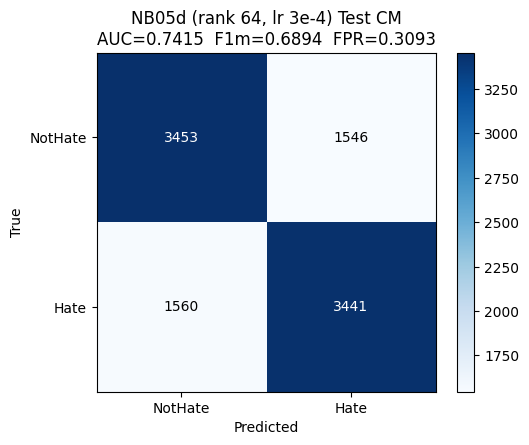

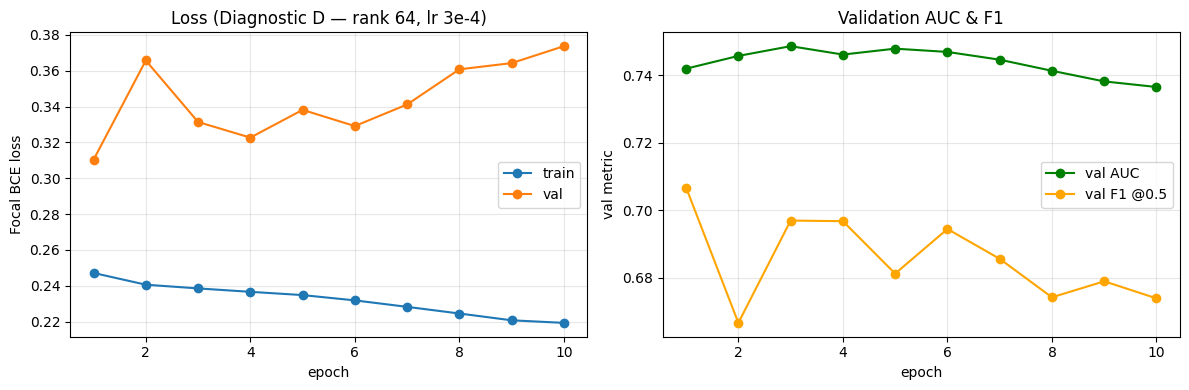

In [8]:
del model
gc.collect(); torch.cuda.empty_cache()

base = AutoModel.from_pretrained(HPARAMS['base_model'])
best_encoder = PeftModel.from_pretrained(base, str(BEST_DIR), is_trainable=False)
head_ckpt = torch.load(BEST_DIR / 'head.pt', map_location='cpu', weights_only=False)
best_head = nn.Linear(base.config.hidden_size, 1)
best_head.load_state_dict(head_ckpt['head'])
print(f'reloaded best (epoch {head_ckpt["epoch"]}, val_auc={head_ckpt["val_auc"]:.4f})')

class _T1Eval(nn.Module):
    def __init__(self, enc, head):
        super().__init__()
        self.encoder = enc; self.head = head
    def forward(self, ids, mask):
        out = self.encoder(input_ids=ids, attention_mask=mask)
        return self.head(out.last_hidden_state[:, 0])

best_model = _T1Eval(best_encoder, best_head).to(device).eval()

all_probs, all_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        y    = batch['label'].cpu().numpy()
        logits = best_model(ids, mask)
        probs = torch.sigmoid(logits.view(-1).float()).cpu().numpy()
        all_probs.append(probs); all_true.append(y)
all_probs = np.concatenate(all_probs); all_true = np.concatenate(all_true)
print(f'test probs: shape={all_probs.shape}, mean={all_probs.mean():.4f}, hate-rate(true)={all_true.mean():.4f}')

test_pred = (all_probs >= HPARAMS['threshold']).astype(int)
auc  = roc_auc_score(all_true, all_probs)
f1m  = f1_score(all_true, test_pred, average='macro')
precm = precision_score(all_true, test_pred, average='macro', zero_division=0)
recm  = recall_score(all_true, test_pred, average='macro', zero_division=0)
cm = confusion_matrix(all_true, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fpr = fp / max(fp + tn, 1)

print(f'\nTEST @ threshold={HPARAMS["threshold"]} (balanced 50/50 test set):')
print(f'  AUC-ROC       : {auc:.4f}')
print(f'  F1   (macro)  : {f1m:.4f}')
print(f'  Precision (M) : {precm:.4f}')
print(f'  Recall    (M) : {recm:.4f}')
print(f'  Confusion     : TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'  FALSE POSITIVE RATE: {fpr:.4f}')

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB05d (rank 64, lr 3e-4) Test CM\nAUC={auc:.4f}  F1m={f1m:.4f}  FPR={fpr:.4f}')
thresh = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig(OUT_DIR / 'nb05_r64_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(history['epoch'], history['train_loss'], '-o', label='train')
a1.plot(history['epoch'], history['val_loss'], '-o', label='val')
a1.set_xlabel('epoch'); a1.set_ylabel('Focal BCE loss')
a1.set_title('Loss (Diagnostic D — rank 64, lr 3e-4)'); a1.legend(); a1.grid(alpha=0.3)
a2.plot(history['epoch'], history['val_auc'], '-o', color='green', label='val AUC')
a2.plot(history['epoch'], history['val_f1'], '-o', color='orange', label='val F1 @0.5')
a2.set_xlabel('epoch'); a2.set_ylabel('val metric')
a2.set_title('Validation AUC & F1'); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb05_r64_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
prior_hate = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    """Bayes shift from 50/50 balanced posterior to deployment prior P(hate)=ph.
    p_recal = (p * ph) / (p * ph + (1-p) * pn)"""
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

val_probs_list, val_true_list = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        mask = batch['attention_mask'].to(device, non_blocking=True)
        logits = best_model(ids, mask)
        val_probs_list.append(torch.sigmoid(logits.view(-1).float()).cpu().numpy())
        val_true_list.append(batch['label'].cpu().numpy())
val_probs_arr = np.concatenate(val_probs_list)
val_true_arr = np.concatenate(val_true_list)

test_probs_recal = recalibrate(all_probs)
val_probs_recal = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    p = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, p)
    if fv > best_thr_f1:
        best_thr_f1 = fv
        best_thr = float(t)
print(f'F1-optimised threshold on RECALIBRATED VAL: {best_thr:.3f}  (val F1={best_thr_f1:.4f})')
print(f'  recalibrated val prob range: [{val_probs_recal.min():.4f}, {val_probs_recal.max():.4f}], mean={val_probs_recal.mean():.4f}')
print(f'  recalibrated test prob range: [{test_probs_recal.min():.4f}, {test_probs_recal.max():.4f}], mean={test_probs_recal.mean():.4f}')

def metrics_at(true_labels, probs, thr):
    pred = (probs >= thr).astype(int)
    auc_  = roc_auc_score(true_labels, probs)
    f1m_  = f1_score(true_labels, pred, average='macro')
    pm_   = precision_score(true_labels, pred, average='macro', zero_division=0)
    rm_   = recall_score(true_labels, pred, average='macro', zero_division=0)
    cm_   = confusion_matrix(true_labels, pred, labels=[0, 1])
    tn, fp, fn, tp = cm_.ravel()
    fpr_  = fp / max(fp + tn, 1)
    return dict(AUC=auc_, F1m=f1m_, Pm=pm_, Rm=rm_, FPR=fpr_,
                TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp))

m_bal_05 = metrics_at(all_true, all_probs, 0.5)
m_rec_opt = metrics_at(all_true, test_probs_recal, best_thr)

print('\n=== SIDE-BY-SIDE METRICS ===')
print(f'  balanced   (50/50 test, threshold = 0.5)')
print(f'  recalibrated (P(hate)={prior_hate}, threshold = {best_thr:.3f}, F1-opt on recal val)')
print(f'  NOTE: AUC is invariant to monotone recalibration -> same value in both columns.\n')
print(f'  {"metric":<14}  {"balanced (50/50, thr=0.5)":<28}  {"recalibrated (~22% hate, thr=F1-opt)":<40}')
for key, name in [('AUC', 'AUC-ROC'), ('F1m', 'F1 (macro)'),
                  ('Pm', 'Precision (M)'), ('Rm', 'Recall (M)'), ('FPR', 'FPR')]:
    print(f'  {name:<14}  {m_bal_05[key]:<28.4f}  {m_rec_opt[key]:<40.4f}')
print(f'  CM balanced     TN={m_bal_05["TN"]:5} FP={m_bal_05["FP"]:5} FN={m_bal_05["FN"]:5} TP={m_bal_05["TP"]:5}')
print(f'  CM recalibrated TN={m_rec_opt["TN"]:5} FP={m_rec_opt["FP"]:5} FN={m_rec_opt["FN"]:5} TP={m_rec_opt["TP"]:5}')

metrics_summary = {
    'run_label': HPARAMS['run_label'],
    'description': 'Diagnostic D: no NB04 warm-start, fresh LoRA rank 64 + lora_alpha 128, lora_lr=3e-4.',
    'best_epoch': int(head_ckpt['epoch']),
    'best_val_auc': float(head_ckpt['val_auc']),
    'pos_weight_used': pos_weight_value,
    'lora_rank': HPARAMS['lora_rank'],
    'lora_alpha': HPARAMS['lora_alpha'],
    'lora_lr': HPARAMS['lora_lr'],
    'thresholds': {
        'balanced_headline': 0.5,
        'recal_f1_optimised_on_recal_val': best_thr,
    },
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    'balanced_test_thr_0.5':      {k: float(v) if not isinstance(v, int) else v for k, v in m_bal_05.items()},
    'recalibrated_test_thr_opt':  {k: float(v) if not isinstance(v, int) else v for k, v in m_rec_opt.items()},
}
print('\nmetrics_summary keys:', list(metrics_summary.keys()))

F1-optimised threshold on RECALIBRATED VAL: 0.210  (val F1=0.7178)
  recalibrated val prob range: [0.1264, 0.4694], mean=0.2675
  recalibrated test prob range: [0.1279, 0.4672], mean=0.2692

=== SIDE-BY-SIDE METRICS ===
  balanced   (50/50 test, threshold = 0.5)
  recalibrated (P(hate)=0.2468, threshold = 0.210, F1-opt on recal val)
  NOTE: AUC is invariant to monotone recalibration -> same value in both columns.

  metric          balanced (50/50, thr=0.5)     recalibrated (~22% hate, thr=F1-opt)    
  AUC-ROC         0.7415                        0.7415                                  
  F1 (macro)      0.6894                        0.6777                                  
  Precision (M)   0.6894                        0.6872                                  
  Recall (M)      0.6894                        0.6806                                  
  FPR             0.3093                        0.4137                                  
  CM balanced     TN= 3453 FP= 1546 FN= 1560 TP=

In [10]:
# Final save to models/roberta_mvp1_d/ — separate path from all previous runs.
if MODEL_DIR.exists() and any(MODEL_DIR.iterdir()):
    for p in list(MODEL_DIR.iterdir()):
        if p.is_file():
            p.unlink()
        elif p.is_dir():
            shutil.rmtree(p)

for src in BEST_DIR.iterdir():
    dst = MODEL_DIR / src.name
    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump(HPARAMS, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print('Saved Diagnostic-D model to', MODEL_DIR)
for p in sorted(MODEL_DIR.iterdir()):
    if p.is_file():
        sz = p.stat().st_size
        unit = 'KB' if sz < 1024**2 else 'MB'
        scale = 1024 if unit == 'KB' else 1024**2
        print(f'  {p.name:>40s}  {sz/scale:>8.2f} {unit}')

# Final comparison across all four runs
this_test_auc = m_bal_05['AUC']
this_test_f1m = m_bal_05['F1m']
this_test_fpr = m_bal_05['FPR']
this_best_val_auc = float(head_ckpt['val_auc'])
this_best_epoch = int(head_ckpt['epoch'])

print('\n=== NB05 RUN COMPARISON ===')
header = (f'{"Run":<6} {"Encoder":<22} {"pos_w":<7} {"r":<3} {"lora_lr":<8} {"Epochs":<8} '
          f'{"Best val AUC":<14} {"Test AUC":<10} {"Test F1m":<10} {"Test FPR":<9}')
print(header)
print('-' * len(header))
print(f'{"Run 1":<6} {"warm-start (NB04)":<22} {"3.57":<7} {"16":<3} {"1e-4":<8} {"5":<8} '
      f'{"0.7457 (ep4)":<14} {"0.7398":<10} {"0.6885":<10} {"0.3071":<9}')
print(f'{"Run 2":<6} {"warm-start (NB04)":<22} {"none":<7} {"16":<3} {"1e-4":<8} {"1 halt":<8} '
      f'{"0.7424 (ep1)":<14} {"n/a":<10} {"n/a":<10} {"n/a":<9}')
print(f'{"Run C":<6} {"FRESH (no NB04)":<22} {"3.57":<7} {"16":<3} {"1e-4":<8} {"5":<8} '
      f'{"0.7447 (ep5)":<14} {"0.7407":<10} {"0.6875":<10} {"0.3069":<9}')
print(f'{"Run D":<6} {"FRESH (no NB04)":<22} {"3.57":<7} {"32":<3} {"3e-4":<8} {str(len(history["epoch"])):<8} '
      f'{f"{this_best_val_auc:.4f} (ep{this_best_epoch})":<14} {f"{this_test_auc:.4f}":<10} '
      f'{f"{this_test_f1m:.4f}":<10} {f"{this_test_fpr:.4f}":<9}')

delta_auc_vs_runC = this_test_auc - 0.7407
delta_f1_vs_runC = this_test_f1m - 0.6875
delta_fpr_vs_runC = this_test_fpr - 0.3069
print(f'\nΔ vs Run C (closest cleanest baseline):')
print(f'  test AUC : {delta_auc_vs_runC:+.4f}')
print(f'  test F1m : {delta_f1_vs_runC:+.4f}')
print(f'  test FPR : {delta_fpr_vs_runC:+.4f}')

# Verdict logic: decision rule from Phase2 report §10.
CEILING_BREAK_AUC = 0.78
CEILING_PLATEAU_BAND = 0.02   # ±0.02 around Run C's 0.7407 counts as 'still plateau'
if this_test_auc >= CEILING_BREAK_AUC:
    verdict_label = 'CEILING BROKEN'
    verdict_text = (f'Test AUC = {this_test_auc:.4f} ≥ {CEILING_BREAK_AUC:.2f}. H3 confirmed: '
                    f'AUC plateau was a LoRA-capacity bottleneck, not the true MMHS150K ceiling. '
                    f'Run D is the new MVP 1 baseline. Downstream MVPs (2-5) compare against {this_test_auc:.4f}.')
elif abs(this_test_auc - 0.7407) <= CEILING_PLATEAU_BAND:
    verdict_label = 'CEILING CONFIRMED'
    verdict_text = (f'Test AUC = {this_test_auc:.4f} is within ±{CEILING_PLATEAU_BAND} of Run C (0.7407). '
                    f'H7 confirmed: ~0.74 is the actual MMHS150K text-only ceiling under PEFT LoRA on '
                    f'cardiffnlp/twitter-roberta-base-2022-154m, robust to rank 16→64 and lr 1e-4→3e-4. '
                    f'MVP 1 baseline is declared at AUC 0.74 as a measured limitation.')
else:
    verdict_label = 'PARTIAL MOVEMENT'
    verdict_text = (f'Test AUC = {this_test_auc:.4f}. Moves outside the Run-C ±{CEILING_PLATEAU_BAND} band '
                    f'but does not clear the {CEILING_BREAK_AUC:.2f} target. Capacity does help but is not sufficient; '
                    f'next ablation should test larger backbone, longer seq, or full fine-tune to confirm H7.')

print(f'\n=== VERDICT: {verdict_label} ===')
print(verdict_text)
print(f'\nNB 05d / Diagnostic D complete. Test AUC = {this_test_auc:.4f} | F1m = {this_test_f1m:.4f} | FPR = {this_test_fpr:.4f}.')

Saved Diagnostic-D model to /teamspace/studios/this_studio/HateFusion/models/rank64/roberta_run_d_r64
                                 README.md      5.08 KB
                       adapter_config.json      1.03 KB
                 adapter_model.safetensors      9.01 MB
                                   head.pt      4.83 KB
                              hparams.json      0.40 KB
                              metrics.json      0.98 KB
                     training_history.json      1.11 KB

=== NB05 RUN COMPARISON ===
Run    Encoder                pos_w   r   lora_lr  Epochs   Best val AUC   Test AUC   Test F1m   Test FPR 
----------------------------------------------------------------------------------------------------------
Run 1  warm-start (NB04)      3.57    16  1e-4     5        0.7457 (ep4)   0.7398     0.6885     0.3071   
Run 2  warm-start (NB04)      none    16  1e-4     1 halt   0.7424 (ep1)   n/a        n/a        n/a      
Run C  FRESH (no NB04)        3.57    16  1e-4   